# Simulazione 3

# Esercizio 1

Si consideri il sistema lineare:

     A  x = b 

dove A è la matrice dei coefficienti, b è il termine noto, ed x è il vettore delle incognite da determinare.
I dati di questo sistema lineare sono contenuti nel file **testI.mat**.

- Si implementino e si testino sui dati forniti due metodi che sono adatti a risolvere tale sistema lineare con le caratteristiche delle matrici dei coefficienti date in input.
                                      **[punti 8]**
- Si confrontino i risultati ottenuti e si giustifichino utilizzando  e richiamando gli aspetti teorici dei metodi implementati.
                                      **[punti 3]**

Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('testI')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``

- Data la matrice
$$
\left[
\begin{array}{cccc}
3.0 &2.0 & 1.0 & -1.0\\
4.0 & 7.0 & 3.0 & 2.0\\
2.0 & 1.0 & 7.0 & 7.0\\
1.0 & 4.0 & 2.0 & 7.0
\end{array}
\right ],
$$
calcolarne la fattorizzazione lu di Gauss  facendo uso della funzione scipy.linalg.lu e:
- sfruttarla per il calcolo del suo determinante (confrontare l'esattezza del calcolo con quello ottenuto usando la funzione numpy.linalg.det)             **[punti: 2]**
- sfruttarla per il calcolo della sua inversa risolvendo n sistemi lineari (confrontare l'inversa con quella ottenuta usando la funzione numpy.linalg.inv)
                                                                                                    **[punti: 2]**

se il raggiospettrale :
* "< 1" --> il metodo converga lla soluzione. L'errore diventa sempre più piccolo a ogni iterazione. Il metodo troverà la soluzione esatta.
* "> = 1" --> il metodo non converge all soluzione. L'errore rimarrà uguale o si ingrandirà a ogni passo. Il computer inizierà a calcolare numeri enormi e privi di senso fino a mandare l'algoritmo in blocco (overflow).

A:  (400, 400)
simmetica:  False
definita positiva:  True
rango massimo:  True
raggio spettrale jacobi 0.48209261553630256
raggio spettrale Gauss-Seidel  0.2889737780164917
detLU:  361.0
det:  360.99999999999983
[[ 0.70914127 -0.32409972 -0.02493075  0.21883657]
 [-0.31301939  0.27977839 -0.05540166 -0.06925208]
 [-0.32963989  0.23268698  0.17174515 -0.28531856]
 [ 0.17174515 -0.1800554  -0.01385042  0.23268698]]
errore sull'inversa:  1.0748346787577413e-16


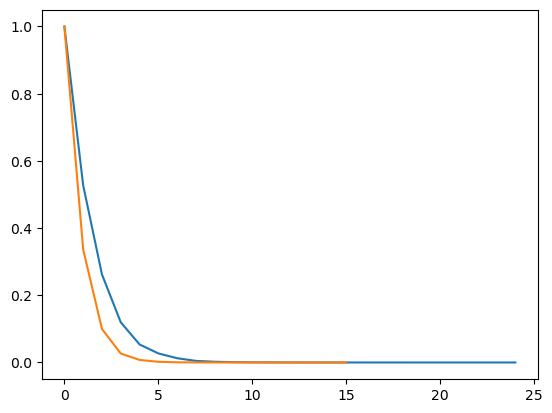

In [14]:
from scipy.io import loadmat

import scipy.linalg as spl
import matplotlib.pyplot as plt
import SolveTriangular as st 
import numpy as np

dati = loadmat('testI')
A=dati["A"] 
A=A.astype(float)
b=dati["b"]
b=b.astype(float)

print("A: ", A.shape)
print("simmetica: ", np.allclose(A, A.T))
autovalori = np.linalg.eigvals(A)
print("definita positiva: ", np.all(autovalori > 0))
print("rango massimo: ", np.linalg.matrix_rank(A) == A.shape[0])

def jacobi(A,b,x0,toll,it_max):          # Definisce una funzione che applica il metodo iterativo di Jacobi
    errore= 1+toll                       

    d= np.diag(A)#to do                        
    D= np.diag(d)#to do 
    n=A.shape[0]                         
    
    E= np.tril(A, -1)#to do 
    F= np.triu(A, 1)#to do 

    M= D#to do 
    N= - (E+F) #to do 
    
    T= np.dot(np.linalg.inv(M), N)#to do 

    autovalori=np.linalg.eigvals(T)     # Calcola gli autovalori della matrice di iterazione T
    raggiospettrale= np.max(np.abs(autovalori))#to do  # Calcola il raggio spettrale

    print("raggio spettrale jacobi", raggiospettrale) # Stampa il raggio spettrale

    it=0                                # Inizializza il contatore delle iterazioni

    er_vet=[]                           # Crea una lista vuota per salvare gli errori a ogni iterazione

    while it < it_max and errore >= toll :#to do 

        x= (b+N@x0)/d.reshape(n, 1)#to do       # Calcola la nuova approssimazione x con la formula di Jacobi

        errore= np.linalg.norm(x-x0) /np.linalg.norm(x) #to do # Calcola l'errore relativo tra due iterazioni successive

        er_vet.append(errore)           # Aggiunge l'errore corrente alla lista degli errori

        x0=x.copy()                     # Aggiorna x0 con la nuova approssimazione x

        it=it+1                         # Incrementa il numero di iterazioni

    return x,it,er_vet                  # Restituisce la soluzione approssimata, il numero di iterazioni e il vettore degli errori

def gauss_seidel(A,b,x0,toll,it_max):   # Definisce la funzione che implementa il metodo iterativo di Gauss-Seidel

    errore=1+toll                      # Inizializza l'errore con un valore maggiore di toll per entrare nel ciclo

    d=np.diag(A)#to do   
    D= np.diag(d)#to do  

    E= np.tril(A, -1)#to do   
    F= np.triu(A, 1) #to do  

    M= D + E#to do  
    N= -F #to do  
    
    T=np.dot(np.linalg.inv(M), N)#to do                             # Costruisce la matrice di iterazione di Gauss-Seidel

    autovalori=np.linalg.eigvals(T)     # Calcola gli autovalori della matrice di iterazione
    raggiospettrale= np.max(np.abs(autovalori))#to do  # Calcola il raggio spettrale 

    print("raggio spettrale Gauss-Seidel ",raggiospettrale) # Stampa il raggio spettrale

    it=0                                # Inizializza il contatore delle iterazioni

    er_vet=[]                           # Lista per salvare l'errore a ogni iterazione

    while it < it_max and errore > toll : #to do  

        x, flag = st.Lsolve(M, b+N@x0)#to do 

        errore= np.linalg.norm(x-x0)/np.linalg.norm(x)# to do Calcola l'errore relativo tra due iterazioni successive

        er_vet.append(errore)           # Salva l'errore corrente

        x0=x.copy()                     # Aggiorna la soluzione per l'iterazione successiva

        it=it+1                         # Incrementa il contatore delle iterazioni

    return x,it,er_vet                  # Restituisce: soluzione approssimata, numero iterazioni, vettore errori

it_max = 100
toll = 1e-8
x0 = np.zeros(A.shape[0]).reshape(A.shape[0], 1)
x,it,er_vet = jacobi(A,b,x0,toll,it_max)
plt.plot(np.arange(it), er_vet)
x,it,er_vet =  gauss_seidel(A,b,x0,toll,it_max)
plt.plot(np.arange(it), er_vet)

A1 = np.array([
    [3.0, 2.0 , 1.0 ,-1.0],
    [4.0,  7.0,  3.0, 2.0],
    [2.0,  1.0,  7.0, 7.0],
    [1.0,  4.0,  2.0, 7.0]
])

# det(A) = det(P) * det(U) Estrae gli elementi che si trovano sulla diagonale principale della matrice $U$. 
#Poiché $U$ è una matrice triangolare superiore (cioè ha tutti zeri sotto la diagonale), il suo determinante è semplicemente il prodotto di questi elementi diagonali.
#Teorema di Binet: È la regola matematica che giustifica il secondo metodo ($\det(A) = \det(P) \cdot \det(L) \cdot \det(U)$). Poiché $\det(L)=1$, pk L ha tutti 1 sulla diagonale,
#ci basta guardare la diagonale di $U$.
P, L, U = spl.lu(A1)
detA1_lu = np.linalg.det(P) * np.prod(np.diag(U))
detA1 = np.linalg.det(A1)
print("detLU: ", detA1_lu)
print("det: ", detA1)

Ainv = np.zeros((4, 4)) #creo matrice di stesse dimensioni di A con solo zeri 
I = np.eye(4) #Genera la matrice Identità 4x4 (quella con tutti 1 sulla diagonale principale e 0 altrove).
for i in range(4) :
    b = I[:, i] #Estrae la colonna corrente della matrice identità (che fa da termine noto del sistema)
    pb = P@b #Moltiplica il termine noto per la matrice di permutazione $P$. Questo serve ad applicare lo stesso scambio di righe (pivoting) fatto durante la scomposizione della matrice iniziale.
    #risolvo il sistema
    y, flag = st.Lsolve(L, pb)
    x, flag = st.Usolve(U, y)
    Ainv[:, i] = x.ravel() #Prende il vettore colonna x appena calcolato, lo "appiattisce" con .ravel() per sicurezza e lo inserisce nella $i$-esima colonna della matrice Ainv
print(Ainv)
print("errore sull'inversa: ", np.linalg.norm(Ainv - np.linalg.inv(A1)) / np.linalg.norm(np.linalg.inv(A1)))

La convergenza di Jacobi e Gauss-Seidel dipende dal raggio spettrale della matrice di iterazione T. Per Jacobi, tutte le componenti del vettore vengono aggiornate utilizzando solo i valori della iterazione precedente, mentre nel metodo di Gauss-Seidel gli aggiornamenti vengono effettuati in modo sequenziale utilizzando anche i valori già aggiornati all’interno della stessa iterazione. Questo comporta che la matrice di iterazione di Gauss-Seidel ha generalmente raggio spettrale minore rispetto a quella di Jacobi e per questo motivo Gauss-Seidel presenta una velocità di convergenza maggiore, confermata sperimentalmente dal minor numero di iterazioni richieste rispetto al metodo di Jacobi.

## Esercizio 2

-  Implementare il  metodo di Newton Raphson, la variante delle corde e la variante di Shamanskii per la soluzione di un sistema di equazioni non  lineari  [**punti: 5**]

Risolvere il sistema di equazioni non lineari

$$
\left\{
\begin{array}{c}
x_0\cdot x_1+x_0=1 \\
 x_0^2+x_1^2=9
\end{array}
\right.
$$
con ciascuno dei tre metodi e confrontare per ciascun metodo il grafico dell'errore relativo tra due iterati successivi, giustificando i risultati alla luce della teoria.  [**punti: 3**]

- Descrivi, teoricamente, la variante del Metodo di Newton-Raphson per calcolare il minimo di una funzione non lineare in più variabili  [**punti: 2**]
 

**Nota Bene**: Servirsi del metodo grafico per individuare un 
iterato iniziale  $X^{(0)}$ nell'intorno della soluzione che si vuole approssimare.  Per fare cio',  visualizzare le 
curve di livello corrisponenti a z=0 delle due superfici $z_1 = f_1 (x_0 ,x_1 )$ e $z_2 = f_2(x_0 , x_1 )$ e 
definire come iterato iniziale un vettore $X^{(0)}=(x_0^{(0)},x_1^{(0)})$ oppurtuno le cui componenti appartengono ad un 
intorno della soluzione (cioè  dei punti di  intersezione tra le curve di livello delle due superfici) \]

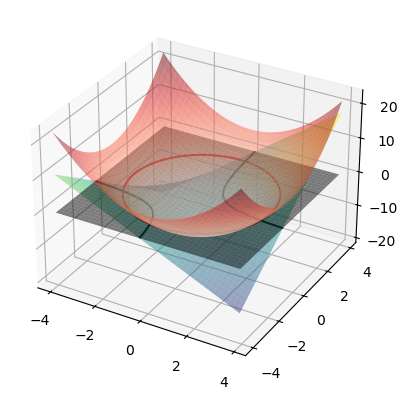

Soluzione Newton-Raphson  [-0.51121549 -2.95612224] Numero di iterazioni Newton-Raphson  4
Soluzione Newton-Raphson-Corde  [-0.5112155  -2.95612224] Numero di iterazioni Newton-Raphson  16
Soluzione Newton-Raphson-Sham  [-0.51121549 -2.95612224] Numero di iterazioni Newton-Raphson  7


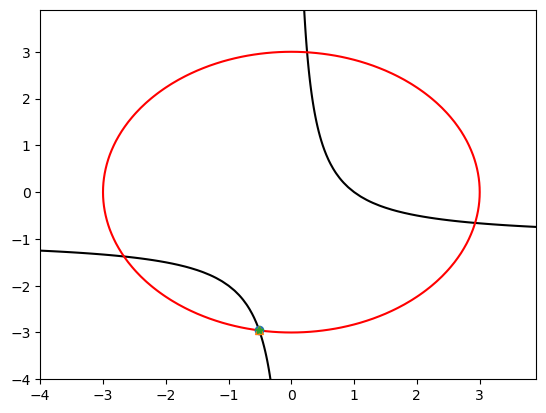

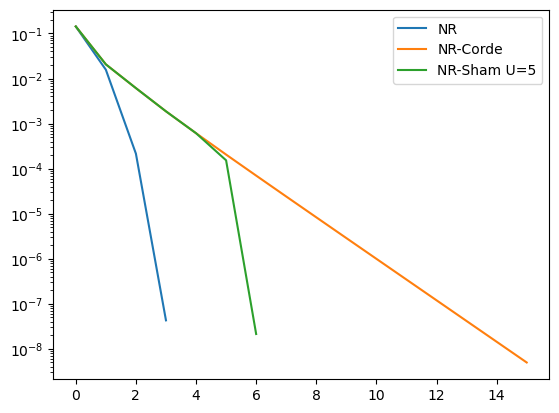

In [22]:
import scipy.linalg as spl
import matplotlib.pyplot as plt
import SolveTriangular as st 
import numpy as np
import sympy as sym
from mpl_toolkits.mplot3d import Axes3D

def newton_raphson(initial_guess, F_numerical, J_numerical, tolX, tolF, max_iterations):
    # Converte la stima iniziale in un array NumPy di float
    X = np.array(initial_guess, dtype=float)

    # Contatore delle iterazioni
    it = 0

    # Inizializzo gli errori con valori maggiori delle tolleranze
    # così il ciclo while parte sicuramente
    erroreF = 1 + tolF
    erroreX = 1 + tolX

    # Lista che conterrà la storia dell'errore relativo sugli iterati
    errore = []

     
    while it < max_iterations and erroreF >= tolF and erroreX >= tolX : #to do 
        # Calcolo della matrice Jacobiana nel punto corrente X
        jx = np.array(J_numerical(X[0],X[1]), dtype = float)#to do 

        if np.linalg.matrix_rank(jx) < jx.shape[0] : #to do 
            print("La matrice Jacobiana calcolata nell'iterato corrente non è a rango massimo")
            return None, None, None

        # Calcolo del valore della funzione F nel punto corrente
        fx = np.array(F_numerical(X[0],X[1]), dtype = float).squeeze() # to do

        
        s = np.linalg.solve(jx, -fx)#to do 

        # Aggiorno l'iterato
        Xnew = X + s#to do 

        # Calcolo dell'errore relativo tra iterati successivi
        # usando la norma 1
        normaXnew = np.linalg.norm(Xnew, 1)
        if normaXnew != 0:
            erroreX = np.linalg.norm(s, 1)/normaXnew#to do 
        else:
            erroreX = np.linalg.norm(s, 1)#to do 

        # Salvo l'errore relativo per analisi successive
        errore.append(erroreX)

        # Calcolo di F nel nuovo punto
        fxnew = np.array(F_numerical(Xnew[0],Xnew[1]), dtype = float).squeeze()#to do 
        erroreF = np.linalg.norm(fxnew, 1)

        # Aggiorno l'iterato corrente
        X = Xnew
        it = it + 1

    # Restituisce:
    # - l'approssimazione della soluzione
    # - il numero di iterazioni eseguite
    # - la lista degli errori relativi sugli iterati
    return X, it, errore

def newton_raphson_corde(initial_guess, F_numerical, J_numerical, tolX, tolF, max_iterations):
    
    # Converte il punto iniziale in array NumPy
    X = np.array(initial_guess, dtype=float)

    # Contatore iterazioni
    it = 0

    # Inizializzazione errori (devono essere > tolleranze per entrare nel ciclo)
    erroreF = 1 + tolF
    erroreX = 1 + tolX

    # Lista per salvare errore relativo sugli iterati
    errore = []

    # La Jacobiana viene calcolata SOLO alla prima iterazione
    # e poi riutilizzata sempre (metodo delle corde)
    
    jx = np.array(J_numerical(X[0],X[1]), dtype = float)#to do
    # Controllo che la Jacobiana sia invertibile
    if np.linalg.matrix_rank(jx) < jx.shape[0] : #to do 
          print("La matrice Jacobiana non è a rango massimo")
          return None, None, None
            
    # Ciclo iterativo
    while it < max_iterations and erroreF >= tolF and erroreX >= tolX :#to do 

        # Valutazione della funzione nel punto corrente
        fx = np.array(F_numerical(X[0],X[1]), dtype = float).squeeze()#to do 

        
        s = np.linalg.solve(jx, -fx)#to do 

        # Aggiornamento dell'iterato
        Xnew = X + s#to do 

        # Calcolo errore relativo tra iterati successivi (norma 1)
        normaXnew = np.linalg.norm(Xnew, 1)
        if normaXnew != 0:
            erroreX = np.linalg.norm(s, 1)/normaXnew#to do 
        else:
            erroreX = np.linalg.norm(s, 1)#to do 

        # Salvataggio errore
        errore.append(erroreX)

        # Calcolo del residuo nel nuovo punto
        fxnew = np.array(F_numerical(Xnew[0],Xnew[1]), dtype = float).squeeze()#to do 
        erroreF = np.linalg.norm(fxnew, 1)

        # Aggiornamento iterato
        X = Xnew
        it = it + 1

    # Output finale
    return X, it, errore

def newton_raphson_sham(initial_guess,F_numerical, J_numerical, tolX, tolF, update, max_iterations):
    
    # Converte il vettore iniziale in un array NumPy di float
    X = np.array(initial_guess, dtype=float)

    # Contatore delle iterazioni
    it = 0

    # Inizializzazione degli errori con valori maggiori delle tolleranze,
    # in modo da entrare sicuramente nel ciclo while
    erroreF = 1 + tolF
    erroreX = 1 + tolX

    # Lista per memorizzare l'errore relativo sugli iterati
    errore = []

    # 
    while  it < max_iterations and erroreF >= tolF and erroreX >= tolX : #to do 
    
        if it % update == 0:
            jx = np.array(J_numerical(X[0],X[1]), dtype = float)#to do 

            # Controlla che la Jacobiana sia invertibile
            if np.linalg.matrix_rank(jx) < jx.shape[0] : #to do 
                print("La matrice Jacobiana calcolata non è a rango massimo")
                return None, None, None

        # Calcola il valore della funzione F nel punto corrente
        fx = np.array(F_numerical(X[0],X[1]), dtype = float).squeeze()#to do 

        s = np.linalg.solve(jx, -fx)#to do 

        # Aggiorna l'iterato
        Xnew = X + s#to do 

        # Calcola l'errore relativo tra iterati successivi usando la norma 1
        normaXnew = np.linalg.norm(Xnew, 1)
        if normaXnew != 0:
            erroreX = np.linalg.norm(s, 1)/normaXnew#to do 
        else:
            erroreX = np.linalg.norm(s, 1)#to do 

        # Salva l'errore relativo nella lista
        errore.append(erroreX)

        # Calcola il residuo nel nuovo punto
        fxnew = np.array(F_numerical(Xnew[0],Xnew[1]), dtype = float).squeeze()#to do 
        erroreF = np.linalg.norm(fxnew, 1)

        # Aggiorna l'iterato corrente e il contatore
        X = Xnew
        it = it + 1

    # Restituisce:
    # - l'approssimazione della soluzione
    # - il numero di iterazioni eseguite
    # - la lista degli errori relativi
    return X, it, errore

x_sym, y_sym = sym.symbols('x_sym y_sym')
def F_sym(f1_sym,f2_sym):
    return sym.Matrix([[f1_sym(x_sym,y_sym)], [f2_sym(x_sym,y_sym)]]) 
f1_sym = lambda x_sym,y_sym: x_sym*y_sym + x_sym - 1   
f2_sym= lambda x_sym,y_sym: x_sym**2+y_sym**2-9  

# Calcolo della matrice Jacobiana simbolicamente
J_sym = F_sym(f1_sym,f2_sym).jacobian(sym.Matrix([x_sym, y_sym]))

# Converte la matrice jacobiana Simbolica in una funzione che può essere valutata numericamente mediante lambdify
J_numerical = sym.lambdify([x_sym, y_sym], J_sym, np)

# Converte il vettore di funzioni Simbolico in una funzione che può essere valutata numericamente mediante lambdify
F_numerical = sym.lambdify([x_sym, y_sym], F_sym(f1_sym,f2_sym), np)

#Disegnare le superfici

# Creazione dei vettori x e y nell'intervallo [-4, 4] con passo 0.1
x = np.arange(-4, 4, 0.1)
y = np.arange(-4, 4, 0.1)

# Creazione della griglia 2D di punti (X, Y)
# X e Y contengono tutte le combinazioni possibili di x e y
X, Y = np.meshgrid(x, y)

# Creazione del piano z = 0 (stessa dimensione della griglia)
Z = np.zeros_like(X)

# Valutazione del sistema non lineare sui punti della griglia
# F_numerical restituisce un vettore con due componenti:
# superfici[0,:,:] = f1(X,Y)
# superfici[1,:,:] = f2(X,Y)
superfici = F_numerical(X, Y).squeeze()

# Creazione della figura 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot della prima superficie z = f1(x,y)
ax.plot_surface(X, Y, superfici[0,:,:], cmap='viridis', alpha=0.5)

# Plot della seconda superficie z = f2(x,y)
ax.plot_surface(X, Y, superfici[1,:,:], cmap='Reds', alpha=0.5)

# Plot del piano z = 0 (serve per visualizzare dove le superfici si annullano)
ax.plot_surface(X, Y, Z, cmap='gray', alpha=0.5)

# Curve di livello z = 0 della prima funzione (f1(x,y) = 0)
plt.contour(X, Y, superfici[0,:,:], levels=[0], colors='black')

# Curve di livello z = 0 della seconda funzione (f2(x,y) = 0)
plt.contour(X, Y, superfici[1,:,:], levels=[0], colors='red')

# Mostra il grafico
plt.show()

initial_guess = [-0.5, -2.5] 
tolx = 1e-8
tolf = 1e-8
itmax = 100
update = 5
Xs_N, it, errore = newton_raphson(initial_guess, F_numerical, J_numerical, tolx, tolf, itmax)
Xs1_N, it1, errore1 = newton_raphson_corde(initial_guess, F_numerical, J_numerical, tolx, tolf, itmax)
Xs2_N, it2, errore2 = newton_raphson_sham(initial_guess, F_numerical, J_numerical, tolx, tolf, update, itmax)
print("Soluzione Newton-Raphson ",Xs_N, "Numero di iterazioni Newton-Raphson ",it)
print("Soluzione Newton-Raphson-Corde ",Xs1_N, "Numero di iterazioni Newton-Raphson ",it1)
print("Soluzione Newton-Raphson-Sham ",Xs2_N, "Numero di iterazioni Newton-Raphson ",it2)

plt.contour(X, Y, superfici[0,:,:], levels=[0], colors='black')
plt.contour(X, Y, superfici[1,:,:], levels=[0], colors='red')
plt.plot(Xs_N[0],Xs_N[1],'o')
plt.plot(Xs1_N[0],Xs1_N[1],'^')
plt.plot(Xs2_N[0],Xs2_N[1],'*')
plt.show()

plt.semilogy(np.arange(it), errore, np.arange(it1), errore1, np.arange(it2), errore2)
plt.legend(["NR", "NR-Corde", "NR-Sham U=" + str(update)])

Per trovare il minimo di una funzione con il metodo di Newton, cerchiamo il punto in cui il gradiente (che indica la pendenza della funzione) diventa piatto, ovvero uguale a zero.

Al posto della classica matrice Jacobiana, si usa la matrice Hessiana, che contiene le derivate seconde e descrive la curvatura della superficie.

A ogni passo, il metodo calcola la direzione migliore verso cui muoversi risolvendo un sistema lineare basato sulla curvatura attuale (la Hessiana) e sulla pendenza attuale (il gradiente), aggiornando la posizione passo dopo passo fino a raggiungere il fondo.

Il punto d'arrivo è un minimo (e non un massimo) se la Hessiana è definita positiva, il che significa che la superficie in quel punto ha una forma a "conca" rivolta verso l'alto.

## Domande Intelligenza Artificiale
**NB: Ogni risposta esatta:  +0.5 punti, ogni risposta errata: -0.5 punti. La mancanza di risposta:  0 punti**

Domande a risposta multipla

**1.** Quale delle seguenti definizioni descrive meglio un'epoca nel training di una rete neurale?
- Il numero di volte in cui viene aggiornato un singolo peso nella rete 
- Il tempo impiegato per completare un ciclo di forward pass e backward propagation
- Il numero di volte in cui l'intero set di dati di training viene esposto alla rete #
- Una misura della complessità del modello di rete neurale

**2.** Per una rete neurale, l’apprendimento è legato a:

•	Minimizzare la funzione obiettivo #

•	Minimizzare la funzione di attivazione

•	Massimizzare il valore dei pesi tramite l’algoritmo di back-propagation

•	Massimizzare il valore della funzione di training


**3.**  Il     Quali di queste affermazioni sono vere: 

    Il layer softmax viene utilizzato per trasformare l’output della rete in probabilità #

    La funzione softmax è continua ma non differenziabile 

    Nell’addestramento di una rete neurale per un task di classificazione binaria, la loss function più comunemente utilizzata è la Binary Cross-Entropy #

    La Categorical Cross-Entropy è una funzione di loss comunemente usata per problemi di regressione a più valori #

**4.**  Quali di queste affermazioni sono vere: Quando si impiega un’architettura di rete esistente: 

  Dato un problema da risolvere, conviene utilizzare un modello con pesi pre-addestrati su un problema simile 

    I pesi di un modello pre-addestrato non sono modificabili 

    È possibile utilizzare un’architettura esistente anche inizializzandone i pesi con valori casuali #

    Architetture di rete differenti possono raggiungere punteggi di accuratezza simili se addestrate sullo stesso dataset #

    Architetture di rete differenti possono raggiungere punteggi di accuratezza differenti se addestrate sullo stesso dataset  dataset 
o dataset 


**5.** A cosa serve il validation set?

•	A trovare i migliori iperparametri del modello #

•	Ad addestrare il modello 

•	A testare il modello

•	A trovare le etichette dei dati di input


**Domande aperte**

Spiegare che cosa si intende per learning rate scheduling, perché è utile durante l’addestramento di una
rete neurale e descrivere le principali strategie: step decay, decadimento esponenziale e decadimento
dipendente dal tempo.. **[punti 1.5]**

Ricavare la formula di aggiornamento dei pesi nel caso di una rete MLP con un nodo di input, due layer
nascosti ciascuno con un solo nodo e un nodo di output, facendo uso dell'algoritmo di back-propagation.
**[punti 3.0 ]**